In [1]:
import openpyxl

print(openpyxl.__version__) #alles in orde als 3.1.5 komt


3.1.5


In [30]:
import pandas as pd
import re #regular regression: parseren van chemische formules
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("bandgap_data.xlsx")
print(df.head())
print(df.columns)

    composition  Eg (eV)
0  Hg0.7Cd0.3Te    0.350
1          CuBr    3.077
2           LuP    1.300
3      Cu3SbSe4    0.400
4           ZnO    3.436
Index(['composition', 'Eg (eV)'], dtype='str')


In [8]:
#opdracht: omzetten Hg0.7Cd0.3Te naar Hg:0.35 Cd:0.15 Te:0.50
formula = "Cu3SbSe4" #beginnen met 1 formule

tokens = re.findall(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)', formula) #([A-Z][a-z]?) zoekt elementen zoals Cu,O,Br
                                                                # ([0-9]*\.?[0-9]*) zoekt een geheel getal/decimaal of niets
print(tokens)

composition = {} #omzetten naar dictionary, gevonden tokens verwerken
for element, amount in tokens:
    if amount == "":
        amount = 1
    else:
        amount = float(amount)

    composition[element] = amount

print(composition)

total = sum(composition.values()) #normaliseren, van aantallen fracties maken

normalized = {}

for element, amount in composition.items():
    normalized[element] = amount / total

print(normalized)

[('Cu', '3'), ('Sb', ''), ('Se', '4')]
{'Cu': 3.0, 'Sb': 1, 'Se': 4.0}
{'Cu': 0.375, 'Sb': 0.125, 'Se': 0.5}


In [15]:
#generaliseren naar de volledige dataset 
def parse_formula(formula): #stap 1: een functie maken 
    tokens = re.findall(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)', formula)

    composition = {}

    for element, amount in tokens:
        if amount == "":
            amount = 1.0
        else:
            amount = float(amount)

        composition[element] = amount

    total = sum(composition.values())

    normalized = {}

    for element, amount in composition.items():
        normalized[element] = amount / total

    return normalized
    
print(parse_formula("Cu3SbSe4")) #controle
print(parse_formula("Hg0.7Cd0.3Te")) #controle

fingerprints = [] #stap 2: de functie toepassen op alle materialen, fingerprint is nu een lijst van dictionaries

for formula in df["composition"]:
    fp = parse_formula(formula)
    fingerprints.append(fp)

fingerprint_df = pd.DataFrame(fingerprints) #stap 3: DataFrame maken hiervan, 

#ontbrekenede elementen worden NaN, vervangen door 0
fingerprint_df = fingerprint_df.fillna(0) #dit is de feature matrix 

fingerprint_df["Eg"] = df["Eg (eV)"] #als target "Eg" is

#stap 4: controleren van alles 
print(fingerprint_df.head())
print(fingerprint_df.shape)
print(fingerprint_df.columns)

{'Cu': 0.375, 'Sb': 0.125, 'Se': 0.5}
{'Hg': 0.35, 'Cd': 0.15, 'Te': 0.5}
     Hg    Cd   Te     Cu   Br   Lu    P     Sb   Se   Zn  ...   Ho    C   Rh  \
0  0.35  0.15  0.5  0.000  0.0  0.0  0.0  0.000  0.0  0.0  ...  0.0  0.0  0.0   
1  0.00  0.00  0.0  0.500  0.5  0.0  0.0  0.000  0.0  0.0  ...  0.0  0.0  0.0   
2  0.00  0.00  0.0  0.000  0.0  0.5  0.5  0.000  0.0  0.0  ...  0.0  0.0  0.0   
3  0.00  0.00  0.0  0.375  0.0  0.0  0.0  0.125  0.5  0.0  ...  0.0  0.0  0.0   
4  0.00  0.00  0.0  0.000  0.0  0.0  0.0  0.000  0.0  0.5  ...  0.0  0.0  0.0   

    Ni   Tc   Re    G   Pm   Xe     Eg  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.350  
1  0.0  0.0  0.0  0.0  0.0  0.0  3.077  
2  0.0  0.0  0.0  0.0  0.0  0.0  1.300  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.400  
4  0.0  0.0  0.0  0.0  0.0  0.0  3.436  

[5 rows x 83 columns]
(6354, 83)
Index(['Hg', 'Cd', 'Te', 'Cu', 'Br', 'Lu', 'P', 'Sb', 'Se', 'Zn', 'O', 'Pt',
       'In', 'S', 'K', 'Sn', 'Ce', 'Pb', 'B', 'Cr', 'Sr', 'Be', 'Nb', 'Pr',
      

In [19]:
#wat is G? 
for formula in df["composition"]:
    if "G" in parse_formula(formula):
        print(formula) 

#we hebben Ga, As, P en G is ? dus oplossen
#hoe? optie 1: lijst maken met alle geldigde chemische elementen: 
valid_elements = {
    "H","He","Li","Be","B","C","N","O","F","Ne",
    "Na","Mg","Al","Si","P","S","Cl","Ar",
    ...,
    "Og"
}
for element, amount in tokens:

    if element not in valid_elements:
        print(f"Waarschuwing: onbekend element '{element}' in {formula}")
        continue
#hoe? optie 2: eerst alle vreemde formules zoeken en dan beslissen of G1128 verwijderd moet of datafout is
for formula in df["composition"]:
    tokens = re.findall(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)', formula)

    for element, amount in tokens:
        if element == "G":
            print(formula)
#conclusie: G1128 is een probleem in de dataset want dit is de enige formule met een G
#probleem in de testcode: Cu, Sb en Se zitten niet in CeZnPO,166

GaAs0.1P0.9G1128
Waarschuwing: onbekend element 'Cu' in CeZnPO,166
Waarschuwing: onbekend element 'Sb' in CeZnPO,166
Waarschuwing: onbekend element 'Se' in CeZnPO,166
GaAs0.1P0.9G1128


In [25]:
#code opschonen en opnieuw 

#1. Lezen van de data 
df = pd.read_excel("bandgap_data.xlsx") 

#2. Alle geldige chemische elementen
valid_elements = {
    'H','He','Li','Be','B','C','N','O','F','Ne',
    'Na','Mg','Al','Si','P','S','Cl','Ar',
    'K','Ca','Sc','Ti','V','Cr','Mn','Fe','Co','Ni','Cu','Zn',
    'Ga','Ge','As','Se','Br','Kr',
    'Rb','Sr','Y','Zr','Nb','Mo','Tc','Ru','Rh','Pd','Ag','Cd',
    'In','Sn','Sb','Te','I','Xe',
    'Cs','Ba','La','Ce','Pr','Nd','Pm','Sm','Eu','Gd','Tb','Dy',
    'Ho','Er','Tm','Yb','Lu',
    'Hf','Ta','W','Re','Os','Ir','Pt','Au','Hg',
    'Tl','Pb','Bi','Po','At','Rn',
    'Fr','Ra','Ac','Th','Pa','U','Np','Pu','Am','Cm','Bk','Cf',
    'Es','Fm','Md','No','Lr',
    'Rf','Db','Sg','Bh','Hs','Mt','Ds','Rg','Cn',
    'Nh','Fl','Mc','Lv','Ts','Og'
}

#3. Opschonen van de formule 
def clean_formula(formula):

    formula = str(formula)

    # alles na een komma verwijderen
    formula = formula.split(",")[0]

    # voorbeeld: GaAs0.1P0.9G1128 -> GaAs0.1P0.9
    #formula = re.sub(r'G\d+$', '', formula)
    # eventueel G1128 verwijderen, formule eerst vragen aan Danny

    return formula
    
#4. Parser
def parse_formula(formula):

    formula = clean_formula(formula)

    tokens = re.findall(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)', formula)

    composition = {}

    for element, amount in tokens:

        # controle op geldige elementen
        if element not in valid_elements:
            print(f"Waarschuwing: onbekend element '{element}' in {formula}")
            continue

        if amount == "":
            amount = 1.0
        else: 
            amount = float(amount)

        # telt aantallen op indien een element meerdere keren voorkomt
        composition[element] = composition.get(element, 0) + amount

    total = sum(composition.values())

    normalized = {}

    for element, amount in composition.items():
        normalized[element] = amount / total

    return normalized


#5. Maak fingerprints
fingerprints = []

for formula in df["composition"]:
    fingerprints.append(parse_formula(formula))
    
#6. Zet om naar DataFrame
fingerprint_df = pd.DataFrame(fingerprints)

fingerprint_df = fingerprint_df.fillna(0)

fingerprint_df["Eg"] = df["Eg (eV)"]

#8. Voer uit controles
print(fingerprint_df.head())
print(fingerprint_df.shape)
print(fingerprint_df.columns)


Waarschuwing: onbekend element 'G' in GaAs0.1P0.9G1128
     Hg    Cd   Te     Cu   Br   Lu    P     Sb   Se   Zn  ...   Nd   Ho    C  \
0  0.35  0.15  0.5  0.000  0.0  0.0  0.0  0.000  0.0  0.0  ...  0.0  0.0  0.0   
1  0.00  0.00  0.0  0.500  0.5  0.0  0.0  0.000  0.0  0.0  ...  0.0  0.0  0.0   
2  0.00  0.00  0.0  0.000  0.0  0.5  0.5  0.000  0.0  0.0  ...  0.0  0.0  0.0   
3  0.00  0.00  0.0  0.375  0.0  0.0  0.0  0.125  0.5  0.0  ...  0.0  0.0  0.0   
4  0.00  0.00  0.0  0.000  0.0  0.0  0.0  0.000  0.0  0.5  ...  0.0  0.0  0.0   

    Rh   Ni   Tc   Re   Pm   Xe     Eg  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.350  
1  0.0  0.0  0.0  0.0  0.0  0.0  3.077  
2  0.0  0.0  0.0  0.0  0.0  0.0  1.300  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.400  
4  0.0  0.0  0.0  0.0  0.0  0.0  3.436  

[5 rows x 82 columns]
(6354, 82)
Index(['Hg', 'Cd', 'Te', 'Cu', 'Br', 'Lu', 'P', 'Sb', 'Se', 'Zn', 'O', 'Pt',
       'In', 'S', 'K', 'Sn', 'Ce', 'Pb', 'B', 'Cr', 'Sr', 'Be', 'Nb', 'Pr',
       'As', 'Ba', 'Ga', 

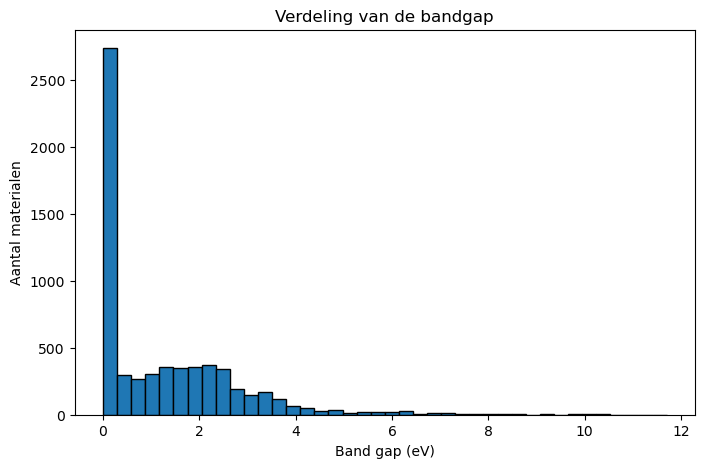

In [23]:
# Nieuwe label maken voor classificatie probleem: Metaal:
# metaal: Eg ~ 0 eV, halfgeleider 0<Eg<3 eV, isolator: Eg> 3 eV

# kijken naar de verdeling
plt.figure(figsize=(8,5))
plt.hist(fingerprint_df["Eg"], bins=40, edgecolor="black")
plt.xlabel("Band gap (eV)")
plt.ylabel("Aantal materialen")
plt.title("Verdeling van de bandgap")
plt.show()


In [39]:
# maken van classificatielabels 

threshold = 0.5 #voorlopig 1 drempel kiezen met -1metaal en 1 = niet-metaal
fingerprint_df["Class"] = np.where(
    fingerprint_df["Eg"] < threshold,
    -1, #metaal 
    1 #niet metaal
)

X = fingerprint_df.drop(columns=["Eg", "Class"])

y = fingerprint_df["Class"]
fingerprint_df.to_excel(
    "chemical_fingerprint.xlsx",
    index=False
)

print(X.shape)
print(y.shape)

print(np.unique(y))
print(np.unique(fingerprint_df["Class"]))
print(fingerprint_df["Class"].value_counts()) #bepaalt hoeveel materialen in elke klasse (evenwicht/onevenwicht)



(6354, 81)
(6354,)
[-1  1]
[-1  1]
Class
 1    3390
-1    2964
Name: count, dtype: int64
